In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
import h5py
import scipy.interpolate
from matplotlib.pyplot import figure
import glob
import imageio.v3 as iio


# from asispectralinversion.inversion import *
# from asispectralinversion.preprocessing import *
# from asispectralinversion.pullfiles import *
from asispectralinversion.filing import *
from asispectralinversion.transformation import *
from asispectralinversion.inversion import *
from asispectralinversion.preprocessing import *
import datetime as dt


#from asi_inv import *
from apexpy import Apex

# Copies an HDF5 structure to a python dict recursively
def copy_h5(vtest):
    # Initialize dict to output
    dicttest = {}
    # List of keys in dataset
    keyslist = list(vtest.keys())
    # Iterate through keys
    for key in keyslist:
        # vtest[key] is an array
        if type(vtest[key]) == h5py._hl.dataset.Dataset:
            # vtest[key] is a 0d or 1d array
            if vtest[key].shape[1] == 1:
                # vtest[key] is a 0d array
                if vtest[key].shape[0] == 1:
                    # extract the float value of vtest[key]
                    dicttest[key] = vtest[key][0][0]
                # vtest[key] is a 1d array
                else:
                    # extract the numpy array
                    dicttest[key] = np.asarray(vtest[key]).flatten()
            # vtest[key] is a 2 or more dimensional array
            else:
                # extract the numpy array
                dicttest[key] = np.asarray(vtest[key])
        # vtest[key] is another hdf5 structure
        else:
            # Recursively apply copy_h5 to the sub-structure
            dicttest[key] = copy_h5(vtest[key])
    return dicttest

# THINGS TO ADD:

## - Add second order inversion

# Set Parameters

In [2]:
date = '20230314'
#date = '20230319'
dtdate = dt.date(int(date[:4]),int(date[4:6]),int(date[6:]))
folder = 'test_data_'+date+'/'

# These aren't necessary with wavelet denoising
# Gaussian blur width in degrees maglon
blur_deg_EW = 0.4
# Gaussian blur width in degrees maglat (should be smaller!)
blur_deg_NS = 0.04

# n_shifts, integer determining shift-invariance of wavelets (higher is better, but slower and has diminishing returns)
n_shifts = 30

# Do we use dark patches in the sky to set background brightness, or just use the corners?
background_method = 'patches'


# Test Inversion
Let's start with a quick self-test: after reading in our inversion tables, we sample RGB brightnesses and see how well we can invert back to what we started with

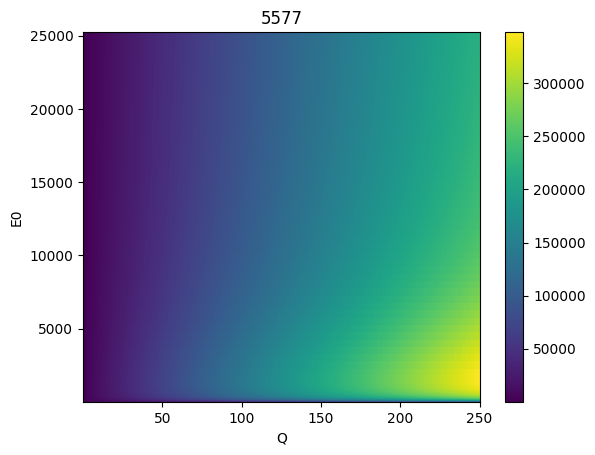

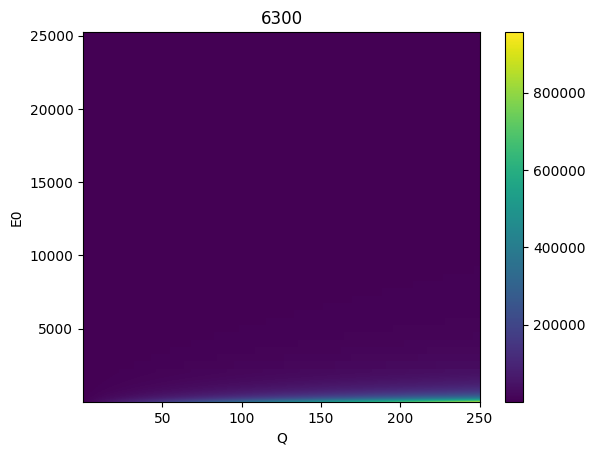

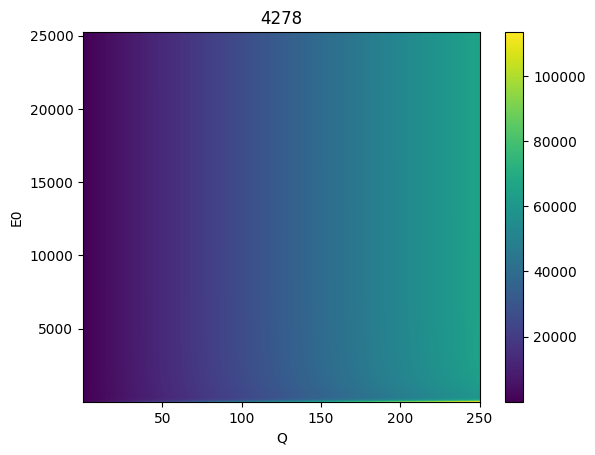

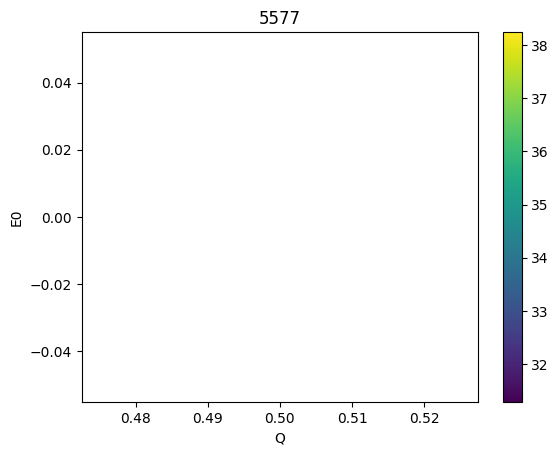

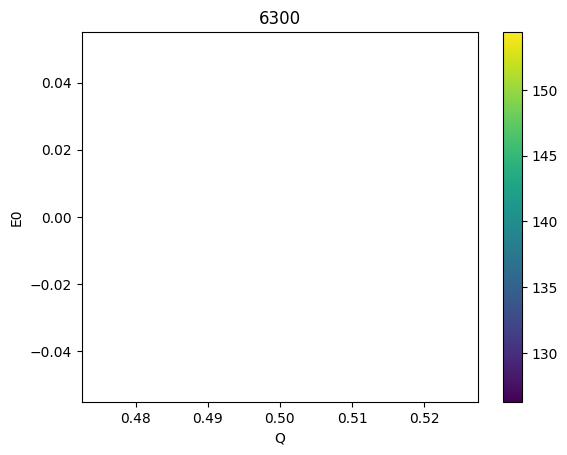

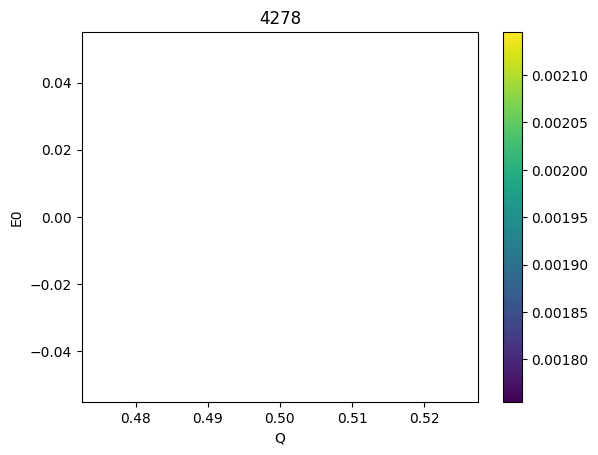

In [3]:
v = load_lookup_tables_directory(folder,plot=True)

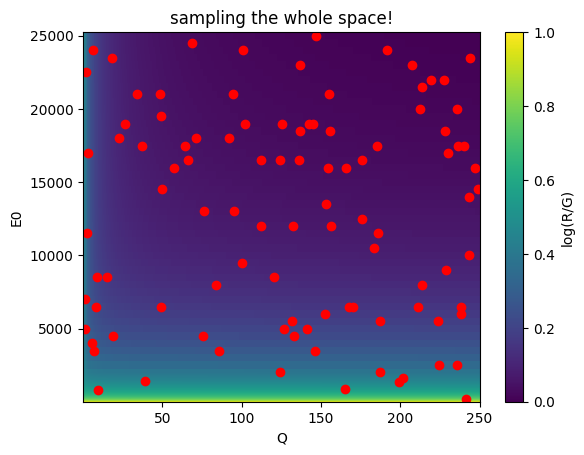

In [4]:
# select random E0 and Q values
randE0 = np.random.random(100)*(np.max(v['E0vec'])-np.min(v['E0vec'])) + np.min(v['E0vec'])
randQ = np.random.random(100)*(np.max(v['Qvec'])-np.min(v['Qvec'])) + np.min(v['Qvec'])

# find closest indices and "snap" to grid
idxE0 = np.array([np.argmin(np.abs(v['E0vec']-E0)) for E0 in randE0])
idxQ = np.array([np.argmin(np.abs(v['Qvec']-Q)) for Q in randQ])
testE0 = v['E0vec'][idxE0]
testQ = v['Qvec'][idxQ]

# Plot
plt.pcolormesh(v['Qvec'],v['E0vec'],np.log(v['redmat']/v['greenmat']))
plt.scatter(testQ,testE0,color='red')
plt.xlabel('Q')
plt.ylabel('E0')
plt.colorbar(label='log(R/G)')
plt.title('sampling the whole space!')
plt.show()


In [5]:
# Pulling out RGB values
redtrace = v['redmat'][idxE0, idxQ]
greentrace = v['greenmat'][idxE0, idxQ]
bluetrace = v['bluemat'][idxE0, idxQ]

# Removing airglow
greentrace -= v['greenbright_airglow'][0][0]
redtrace -= v['redbright_airglow'][0][0]
bluetrace -= v['bluebright_airglow'][0][0]


## Three-Color Inversion
This is the standard and prefered technique.

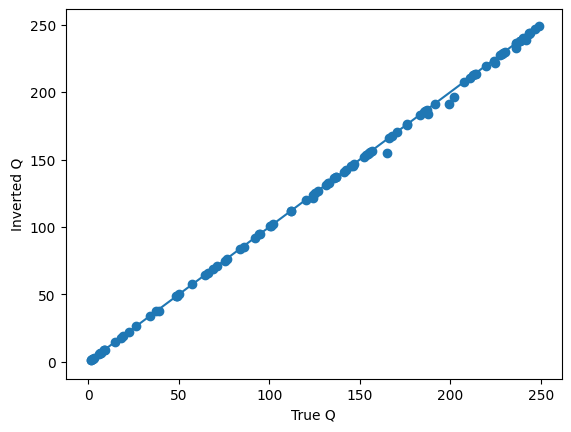

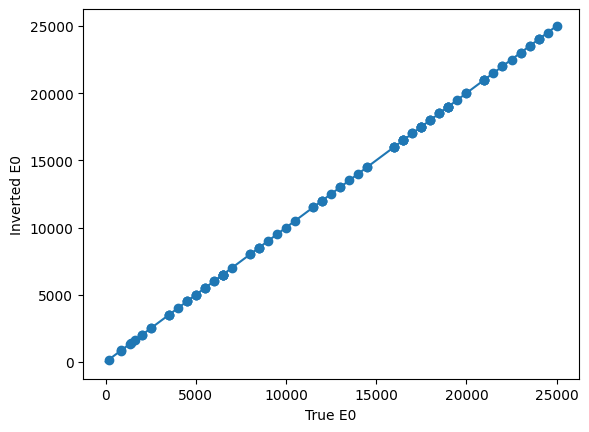

In [6]:
# Calculate E0 and Q from inversion
outQ, outE0 = calculate_E0_Q_v2(redtrace, greentrace, bluetrace, v, minE0=150, secondorder=True, generous=True, plot=False)

# Plot
plt.scatter(testQ, outQ)
plt.plot([0, np.max(testQ)], [0, np.max(testQ)])
plt.xlabel('True Q')
plt.ylabel('Inverted Q')
plt.show()

plt.scatter(testE0, outE0)
plt.plot([0, np.max(testE0)], [0, np.max(testE0)])
plt.xlabel('True E0')
plt.ylabel('Inverted E0')
plt.show()


In [7]:
# Assess variance from truth value
print('Q chi2:', np.sum((outQ-testQ)**2/testQ))
print('Q med %err:', np.median(np.abs(outQ-testQ)/testQ*100.))
print('E0 chi2:', np.sum((outE0-testE0)**2/testE0))
print('E0 med %err:', np.median(np.abs(outE0-testE0)/testE0*100.))


Q chi2: 1.4960107
Q med %err: 0.047467478
E0 chi2: 0.0020300818
E0 med %err: 0.00043305894


## Red-Green Only
This is an experimental technique that may be useful if there are only two cameras available.

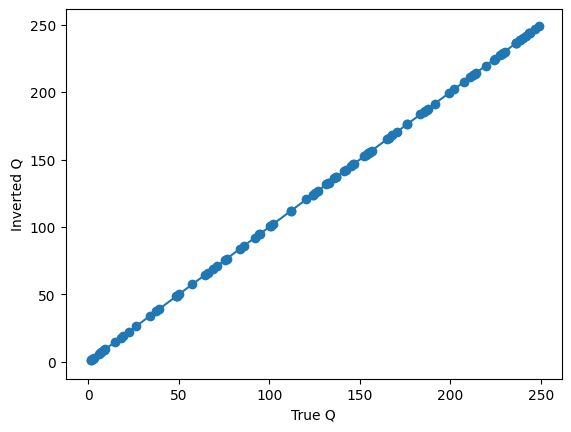

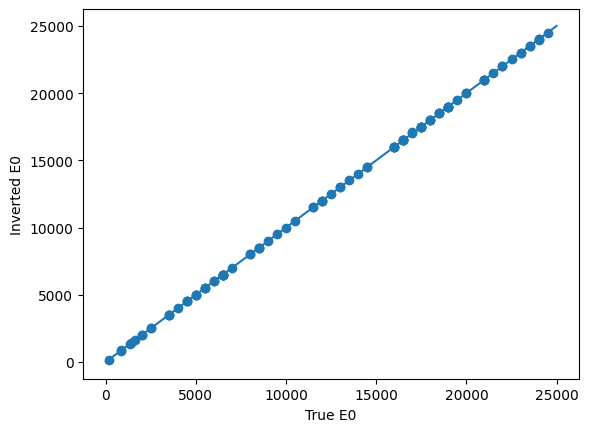

In [8]:
# Calculate E0 and Q from inversion
outQ, outE0 = calculate_E0_Q_v2_RGonly(redtrace,greentrace,bluetrace,v,minE0=150,checkagreement=False,cutoffgoodness=0.3,plot=False)

# Plot
plt.scatter(testQ, outQ)
plt.plot([0, np.max(testQ)], [0, np.max(testQ)])
plt.xlabel('True Q')
plt.ylabel('Inverted Q')
plt.show()

plt.scatter(testE0, outE0)
plt.plot([0, np.max(testE0)], [0, np.max(testE0)])
plt.xlabel('True E0')
plt.ylabel('Inverted E0')
plt.show()


In [9]:
# Assess variance from truth value
print('Q chi2:', np.sum((outQ-testQ)**2/testQ))
print('Q med %err:', np.median(np.abs(outQ-testQ)/testQ*100.))
print('E0 chi2:', np.sum((outE0-testE0)**2/testE0))
print('E0 med %err:', np.median(np.abs(outE0-testE0)/testE0*100.))


Q chi2: 0.03854558832632865
Q med %err: 0.00017551475365361287
E0 chi2: nan
E0 med %err: nan


# Inversion of Imagry Data
Same technique, but applied to images from the UAF GI optics database. If the following cell doesn't work to download data automatically, images can be retreived from the [Poker Flat Optics Archive](https://optics.gi.alaska.edu/amisr_archive/PKR/DASC/PNG/).

In [10]:
# For 0314, the Swarm crossing of the arc happens at roughly 6:48 - 6:50 UT.
# Change this manually as needed
starttime = dt.time(6,48)
endtime = dt.time(6, 50)

# Download all DASC imagery between these times to a local directory:
download_imagery(dtdate, starttime, endtime, folder)

2023-03-14 06:48:00 06:50:00
Building link to archive...
http://optics.gi.alaska.edu/amisr_archive/PKR/DASC/PNG/2023/20230314/06


SSLError: HTTPSConnectionPool(host='optics.gi.alaska.edu', port=443): Max retries exceeded with url: /amisr_archive/PKR/DASC/PNG/2023/20230314/06 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)')))

## Read Images
Read images from png files.

In [11]:
# Change this manually as needed, it is set up for 0314

# Read in red images
redim0 = iio.imread(folder+'/PKR_20230314_064904_0630.png')
redim1 = iio.imread(folder+'/PKR_20230314_064912_0630.png')
redim2 = iio.imread(folder+'/PKR_20230314_064920_0630.png')

# Read in green images
greenim0 = iio.imread(folder+'/PKR_20230314_064902_0558.png')
greenim1 = iio.imread(folder+'/PKR_20230314_064910_0558.png')
greenim2 = iio.imread(folder+'/PKR_20230314_064918_0558.png')

# Read in blue images
blueim0 = iio.imread(folder+'/PKR_20230314_064859_0428.png')
blueim1 = iio.imread(folder+'/PKR_20230314_064907_0428.png')
blueim2 = iio.imread(folder+'/PKR_20230314_064915_0428.png')



## Read Skymap Files
Skymap files map each pixel in the image to specific geodetic coordinates.  The skymap files provided in the default folders have already performed magnetic mapping of each emission line to 110 km.  The files provide geodetic coordinates.

Note that there are separate copies of identical skymaps in each folder.  We anticipate eventually using different skymaps, so this was done to start the bookkeeping for that process

In [14]:
# Read in the skymap and extract the values for each color
with h5py.File(folder+'skymap.mat', 'r') as h5:
        skymapred = [h5['/magnetic_footpointing/180km/lat'][:],
                     h5['/magnetic_footpointing/180km/lon'][:]]
        skymapgreen = [h5['/magnetic_footpointing/110km/lat'][:],
                       h5['/magnetic_footpointing/110km/lon'][:]]
        skymapblue = [h5['/magnetic_footpointing/107km/lat'][:],
                      h5['/magnetic_footpointing/107km/lon'][:]]


## Image Preparation
### Co-Add Frames
We typically average the brightness from three sucessive frames.  This supresses noise slightly.

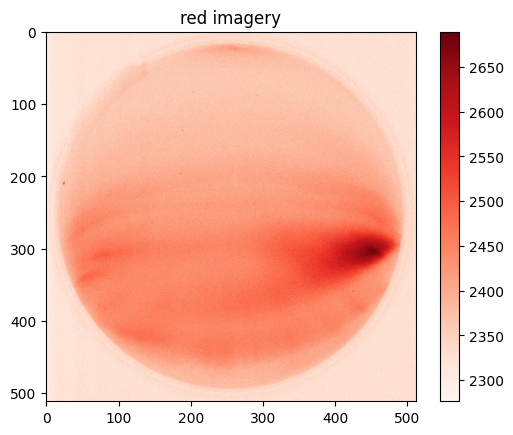

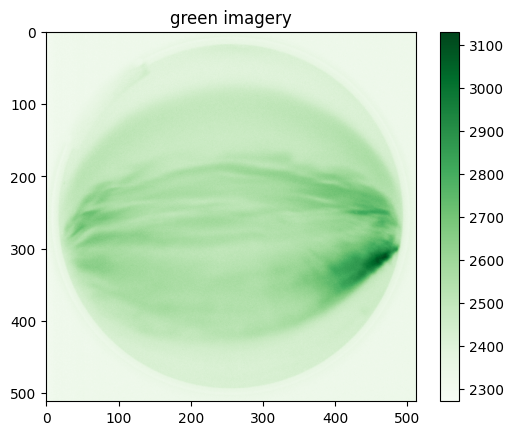

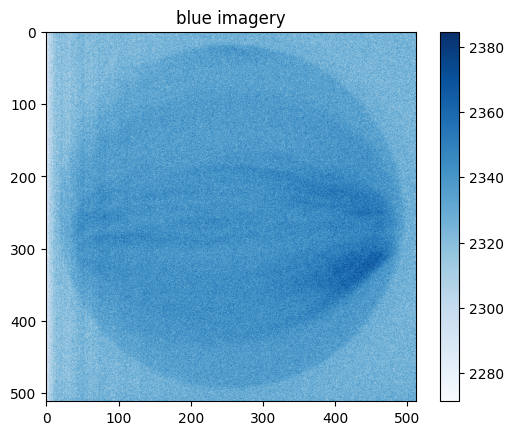

In [16]:
# Co-add the images
redimcoadd = (redim0+redim1+redim2)/3
greenimcoadd = (greenim0+greenim1+greenim2)/3
blueimcoadd = (blueim0+blueim1+blueim2)/3

plt.imshow(redimcoadd, cmap='Reds')
plt.title('red imagery')
plt.colorbar()
plt.show()
plt.imshow(greenimcoadd, cmap='Greens')
plt.colorbar()
plt.title('green imagery')
plt.show()
plt.imshow(blueimcoadd, cmap='Blues')
plt.colorbar()
plt.title('blue imagery')
plt.show()

### Dark Frame Subtraction
The blue imagery has significant artifacts, so let's try a dark frame subtraction!  This is not necessarily a standard step.

In [17]:
blueimcoaddold = np.copy(blueimcoadd)
darkframe = iio.imread('biasframes/blue_bias_processed.png').astype('float')/10
darkframe -= np.mean(darkframe)

In [18]:
rawdarkframe = iio.imread('biasframes/blue_bias_raw.png').astype('float')/10
rawdarkframe -= np.mean(rawdarkframe)

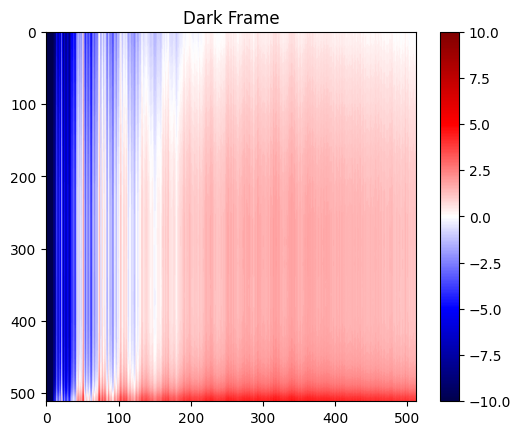

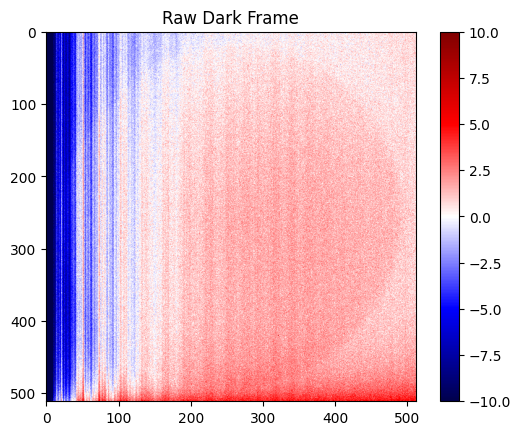

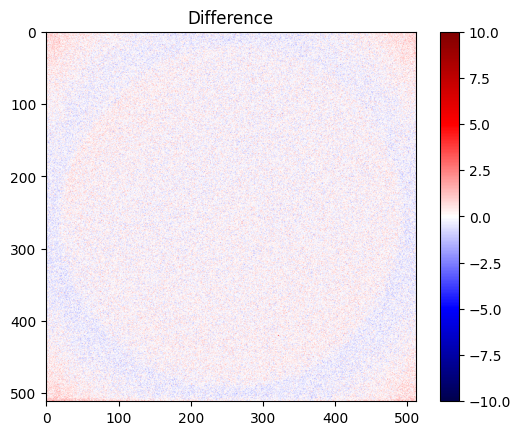

In [20]:
plt.imshow(darkframe,vmin=-10,vmax=10,cmap='seismic')
plt.colorbar()
plt.title('Dark Frame')
plt.show()
plt.imshow(rawdarkframe,vmin=-10,vmax=10,cmap='seismic')
plt.colorbar()
plt.title('Raw Dark Frame')
plt.show()
plt.imshow(rawdarkframe-darkframe,vmin=-10,vmax=10,cmap='seismic')
plt.colorbar()
plt.title('Difference')
plt.show()

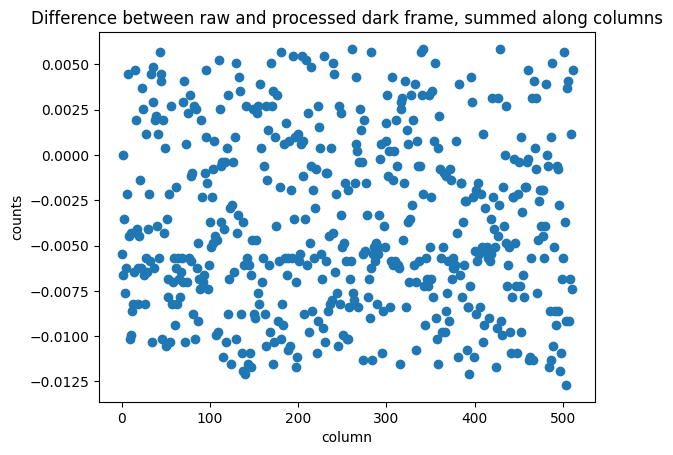

Text(0.5, 0, 'column')

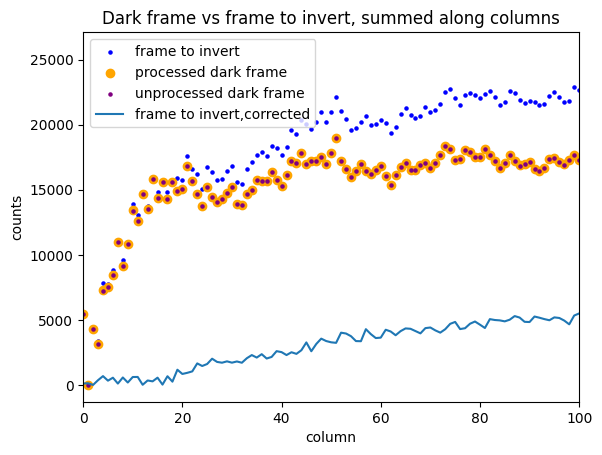

In [21]:
plt.scatter(np.linspace(0,511,512),((np.sum(rawdarkframe,axis=0)-np.amin(np.sum(rawdarkframe,axis=0)))-((np.sum(darkframe,axis=0)-np.amin(np.sum(darkframe,axis=0)))))/512,label='processed dark frame')
plt.title('Difference between raw and processed dark frame, summed along columns')
plt.ylabel('counts')
plt.xlabel('column')
plt.show()
plt.title('Dark frame vs frame to invert, summed along columns')
plt.scatter(np.linspace(0,511,512),np.sum(blueimcoaddold,axis=0)-np.amin(np.sum(blueimcoaddold,axis=0)),s=5,color='blue',label='frame to invert')
plt.scatter(np.linspace(0,511,512),(np.sum(darkframe,axis=0)-np.amin(np.sum(darkframe,axis=0))),color='orange',label='processed dark frame')
plt.scatter(np.linspace(0,511,512),(np.sum(rawdarkframe,axis=0)-np.amin(np.sum(rawdarkframe,axis=0))),s=5,color='purple',label='unprocessed dark frame')
plt.plot(np.linspace(0,511,512),np.sum(blueimcoaddold-darkframe,axis=0)-np.amin(np.sum(blueimcoaddold-darkframe,axis=0)),label='frame to invert,corrected')

plt.legend()
plt.xlim(0,100)
plt.ylabel('counts')
plt.xlabel('column')


In [22]:
blueimcoadd = blueimcoaddold-darkframe

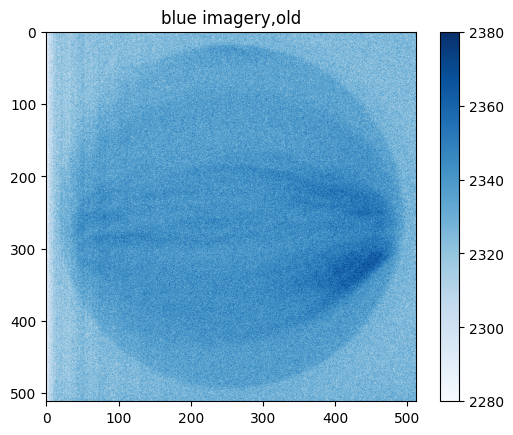

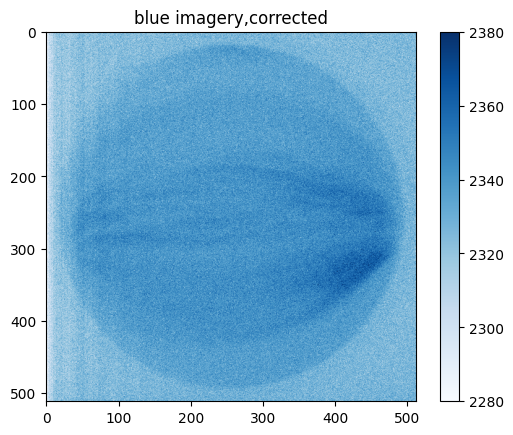

In [22]:
plt.imshow(blueimcoaddold,vmin=2280,vmax=2380, cmap='Blues')
plt.title('blue imagery,old')
plt.colorbar()
plt.show()
plt.imshow(blueimcoadd,vmin=2280,vmax=2380, cmap='Blues')
plt.title('blue imagery,corrected')
plt.colorbar()
plt.show()
# plt.imshow(blueimcoaddold-rawdarkframe,vmin=2280,vmax=2380)
# plt.title('blue imagery,corrected alternate')
# plt.colorbar()
# plt.show()

### Estimating Background Brightness

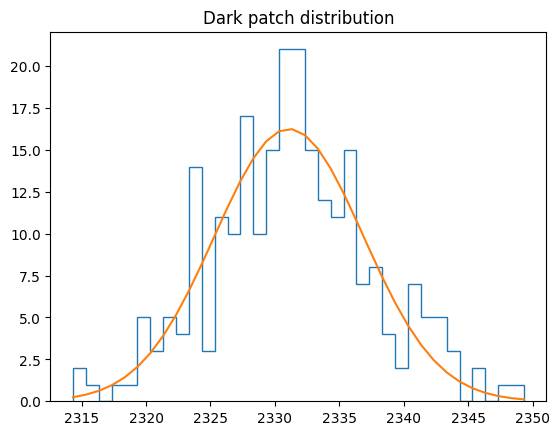

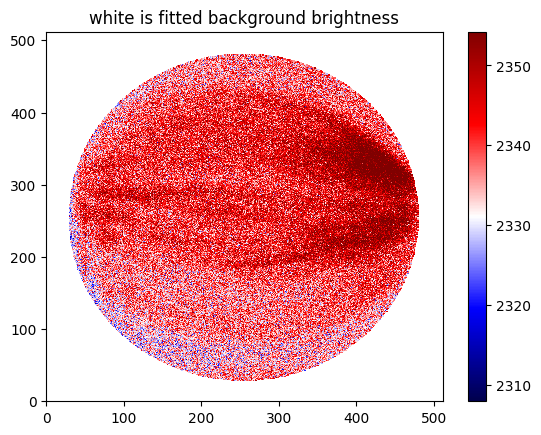

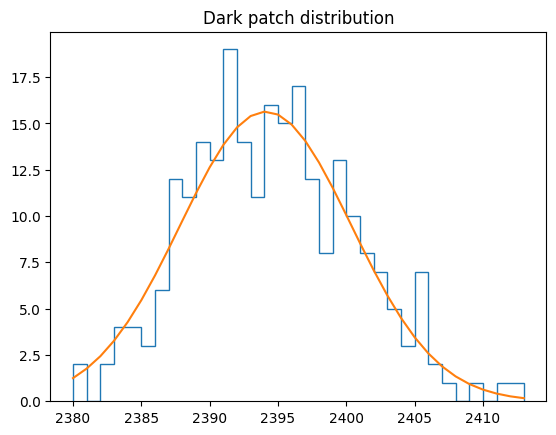

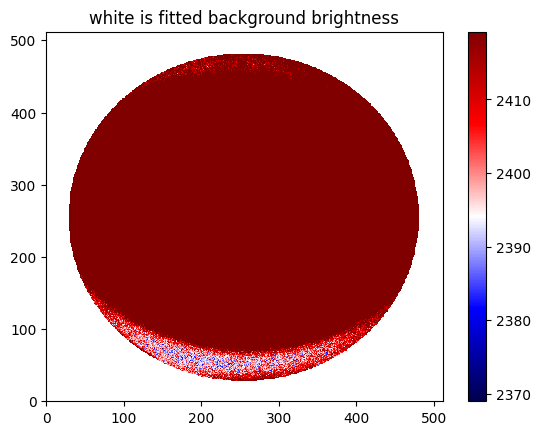

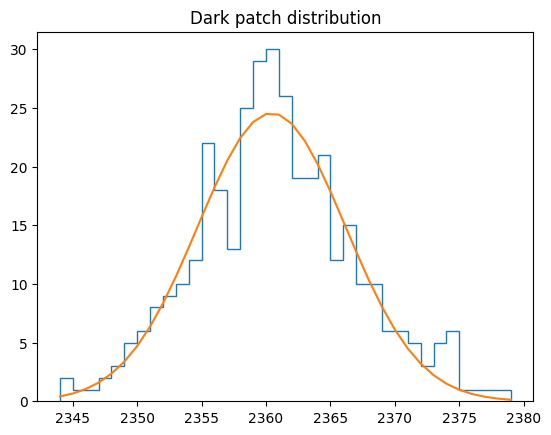

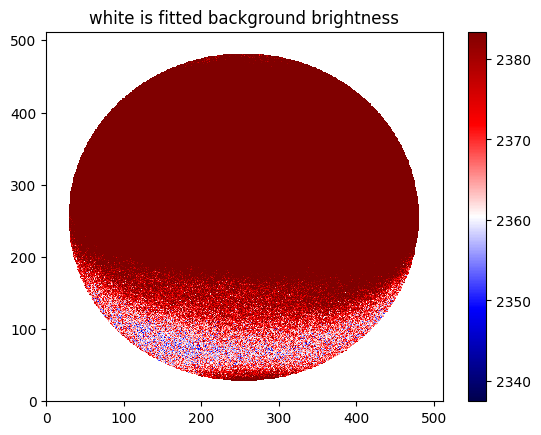

In [23]:
# Define masks where image not defined
bmask = np.isnan(skymapblue[0])
gmask = np.isnan(skymapgreen[0])
rmask = np.isnan(skymapred[0])


# Calculate background brightness
bluebgbright, bluesig = background_brightness(blueimcoadd, bmask, background_method=background_method, plot=True)
greenbgbright, greensig = background_brightness(greenimcoadd, gmask, background_method=background_method, plot=True)
redbgbright, redsig = background_brightness(redimcoadd, rmask, background_method=background_method, plot=True)


### Regridding
The skymap file contains the coordinates of all three images magnetically mapped to 110 km.  We want to define a regular geodetic grid and interpolat all three images to that grid.

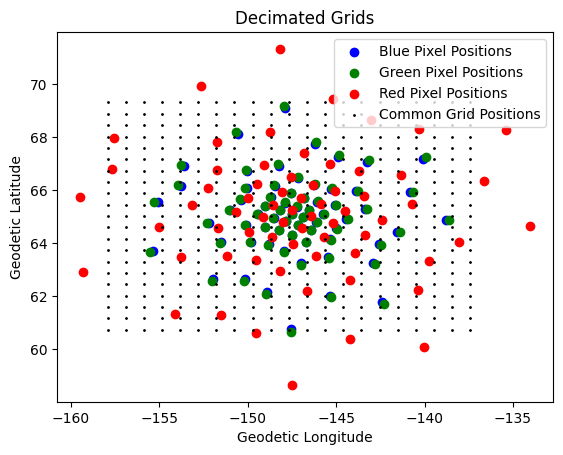

interpolate image...
interpolate image...
interpolate image...


In [40]:
bglat, bglon = skymapblue
gglat, gglon = skymapgreen
rglat, rglon = skymapred

gridlat, gridlon = common_grid(bglat, bglon, gglat, gglon, rglat, rglon)

plt.scatter(bglon[::50,::50], bglat[::50,::50], color='blue', label='Blue Pixel Positions')
plt.scatter(gglon[::50,::50], gglat[::50,::50], color='green', label='Green Pixel Positions')
plt.scatter(rglon[::50,::50], rglat[::50,::50], color='red', label='Red Pixel Positions')
plt.scatter(gridlon[::50,::50], gridlat[::50,::50], color='black', s=1, label='Common Grid Positions')
plt.legend()
plt.xlabel('Geodetic Longitude')
plt.ylabel('Geodetic Latitude')
plt.title('Decimated Grids')
plt.show()

# Interpolate images to new magnetic grid
blueimreg = interpolate_reggrid(blueimcoadd, bglon, bglat, gridlon, gridlat)
greenimreg = interpolate_reggrid(greenimcoadd, gglon, gglat, gridlon, gridlat)
redimreg = interpolate_reggrid(redimcoadd, rglon, rglat, gridlon, gridlat)

# Grid steps for our new common grid - the new grid is very nearly Cartesian in footlat/footlon
dlon = np.mean(np.diff(gridlon, axis=0))
dlat = np.mean(np.diff(gridlat, axis=1))


### Wavelet Denoising
We use a Bayesian wavelet based denoising algorithm to blur the image as little as possible.
nshifts is a parameter controlling the shift-invariance of the wavelets, and should probably be set between 5 and 70, or so... 
Here we set nshifts=30 to speed up computation, but its default value is 50 (I probably set it higher than necessary)

wavelet denoise...


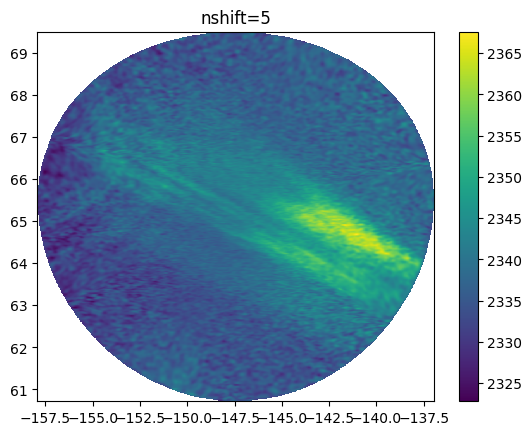

wavelet denoise...


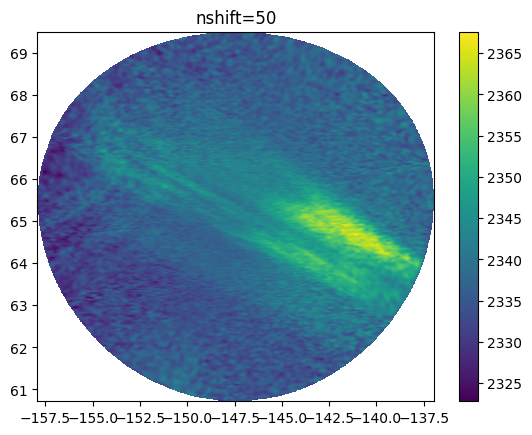

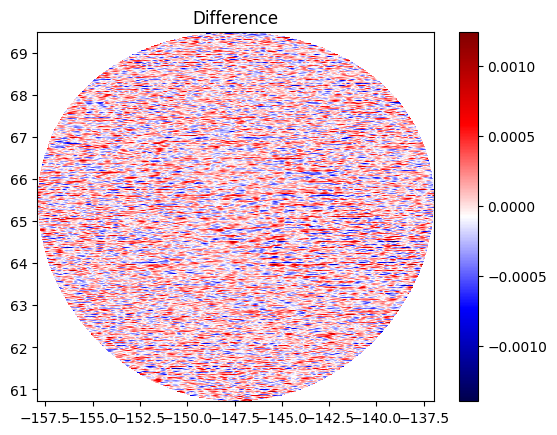

In [50]:
blueimdenoisewavelet1 = wavelet_denoise(blueimreg, dlat, dlon, bluebgbright, nshifts=5)
plt.pcolormesh(gridlon, gridlat, blueimdenoisewavelet1)
plt.colorbar()
plt.title('nshift=5')
plt.show()

blueimdenoisewavelet2 = wavelet_denoise(blueimreg, dlat, dlon, bluebgbright, nshifts=50)
plt.pcolormesh(gridlon, gridlat, blueimdenoisewavelet2)
plt.colorbar()
plt.title('nshift=50')
plt.show()

plt.pcolormesh(gridlon, gridlat, blueimdenoisewavelet2-blueimdenoisewavelet1, cmap='seismic')
plt.colorbar()
plt.title('Difference')
plt.show()

#### Compare Against Simulated Noise
Let's compare the residual from denoising to a simulated noise field from our background fitting

I'm very confused by this comparison.

In [55]:
noise = np.copy(skymapblue[0]).reshape(-1)
print(noise.shape)
# plt.plot(noise)

# These are the corners??
print(len(noise[np.where(~np.isnan(noise))]))

noiseadd = (np.random.randn(len(noise[np.where(~np.isnan(noise))]))*bluesig)
noise[np.where(~np.isnan(noise))] = noiseadd
noise = noise.reshape(skymapblue[0].shape)

(262144,)
159964


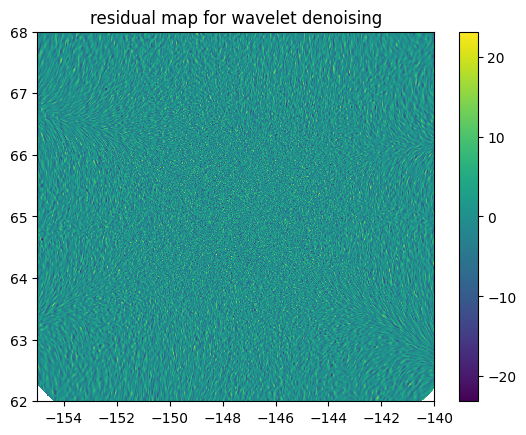

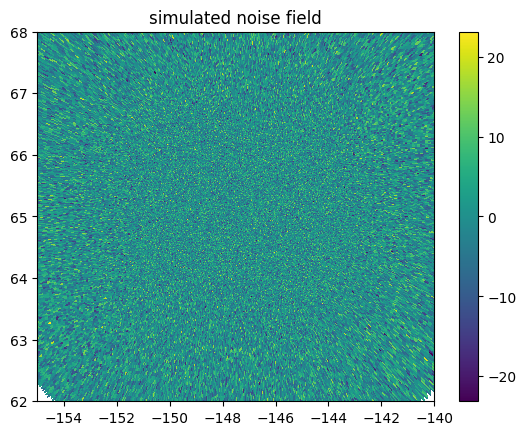

In [56]:
plt.pcolormesh(gridlon,gridlat,blueimreg-blueimdenoisewavelet,vmin=-4*bluesig,vmax=4*bluesig)
plt.title('residual map for wavelet denoising')
plt.xlim(-155,-140)
plt.ylim(62,68)
plt.colorbar()
plt.show()
plt.title('simulated noise field')
plt.pcolor(skymapgreen[1],skymapgreen[0],noise,vmin=-4*bluesig,vmax=4*bluesig)
plt.xlim(-155,-140)
plt.ylim(62,68)
plt.colorbar()


#### Apply Wavelet Denoising to All Three Channels

In [57]:
# Wavelet Denoise
blueimdenoise = wavelet_denoise(blueimreg, dlat, dlon, bluebgbright, nshifts=n_shifts)
greenimdenoise = wavelet_denoise(greenimreg, dlat, dlon, greenbgbright, nshifts=n_shifts)
redimdenoise = wavelet_denoise(redimreg, dlat, dlon, redbgbright, nshifts=n_shifts)


wavelet denoise...
wavelet denoise...
wavelet denoise...


### Visualize All Three Channels
Combine all three colors with RGB.  Just for visualization.

Text(0.5, 1.0, 'mapped image, original, geodetic coords')

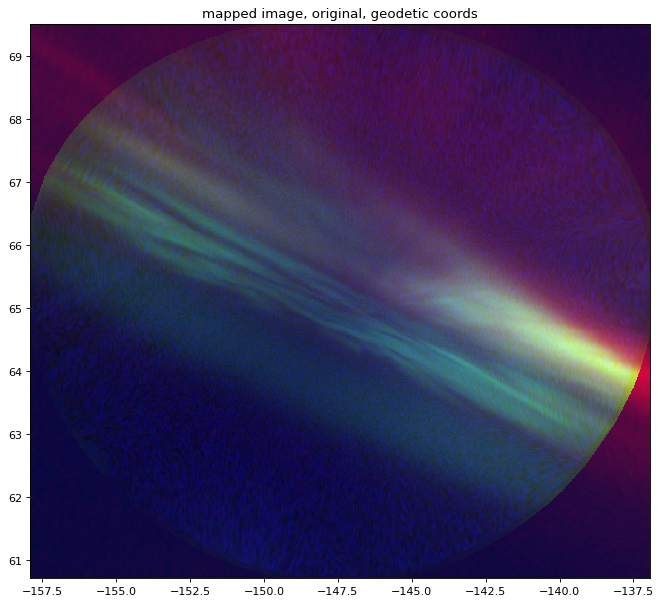

In [58]:
# This is just a visualization tool - we tried to strike a balance between brightening the dim colors and allowing them to overwhelm the image

ngreen = (1/np.std(greenimreg[np.where(~np.isnan(greenimreg))]))**(6.5/8)
nred = (1/np.std(redimreg[np.where(~np.isnan(redimreg))]))**(6.5/8)
nblue = (1/np.std(blueimreg[np.where(~np.isnan(blueimreg))]))**(6.5/8)

greenframe = np.copy(greenimreg)
greenframe[np.where(np.isnan(greenframe))] = greenbgbright

blueframe = np.copy(blueimreg)
blueframe[np.where(np.isnan(blueframe))] = bluebgbright

redframe = np.copy(redimreg)
redframe[np.where(np.isnan(redframe))] = redbgbright


greenmin = np.amin(greenframe)
bluemin = np.amin(blueframe)
redmin = np.amin(redframe)

# ngreen=100/np.median(greenframe-greenmin)
# nred = 100/np.median(redframe-redmin)
# nblue=100/np.median(blueframe-bluemin)


#colormat = np.asarray([3*(redframe-redmin),(greenframe-greenmin),10*(blueframe-bluemin)]).astype(float)
colormat = np.asarray([nred*(redframe-redmin),ngreen*(greenframe-greenmin),nblue*(blueframe-bluemin)]).astype(float)

maxbright = np.amax(colormat)

colormat /= maxbright

fig = figure(figsize=(10, 9), dpi=80)
fig.canvas.header_visible = False
mesh = plt.pcolormesh(gridlon.T,gridlat.T,greenframe.T,facecolors=colormat.T.reshape(-1,3))
mesh.set_array(None)
plt.title('mapped image, original, geodetic coords')

### Convert to Rayleighs
Now we have the preprocessed image, let's convert it to Rayleighs according to the *approximate* nominal calibrations.  Use the radioactive source calibrations to *roughly* convert counts to rayleighs.

In [59]:
redray,greenray,blueray = to_rayleighs(redimdenoise,greenimdenoise,blueimdenoise,redbgbright,greenbgbright,bluebgbright)

### NaN Invalid Pixels
Unfortunately we almost certainly have a few pixels that have negative brightnesses - we could set these to zeros, but we set them to NaNs

In [60]:
badrange = np.where(np.isnan(redray+blueray+greenray))
redray[badrange] = np.nan
greenray[badrange] = np.nan
blueray[badrange] = np.nan

In [61]:
negatives = np.zeros_like(blueray)
negatives[np.where( (redray<0) | (blueray<0) | (greenray<0) )] = 1
negatives[np.where(np.isnan(blueray))] = np.nan

Text(0.5, 1.0, 'Yellow is regions where any brightnesses are negative')

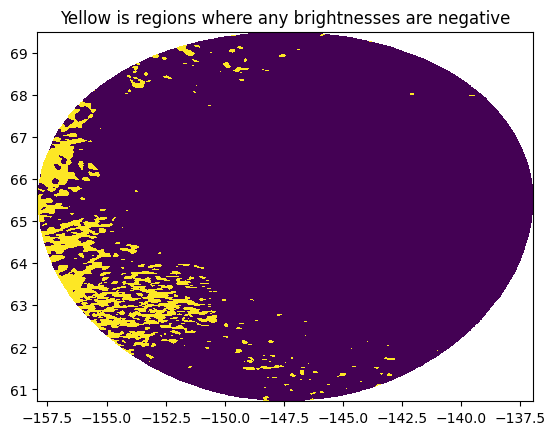

In [62]:
plt.pcolormesh(gridlon,gridlat,negatives)
plt.title('Yellow is regions where any brightnesses are negative')

In [63]:
redray[np.where(redray<0)]=np.nan
greenray[np.where(greenray<0)]=np.nan
blueray[np.where(blueray<0)]=np.nan
badrange = np.where(np.isnan(redray+blueray+greenray))

redray[badrange] = np.nan
greenray[badrange] = np.nan
blueray[badrange] = np.nan

### Decimate
This is only for time efficiency.  Note that dec=2 returns the original resolution, so there is no advantage to dec=1.

In [64]:
# Note: dec=2 returns the original resolution, no need to do dec=1
dec = 8

redraydec = redray[::dec,::dec]
blueraydec = blueray[::dec,::dec]
greenraydec = greenray[::dec,::dec]
decgridlat = gridlat[::dec,::dec]
decgridlon = gridlon[::dec,::dec]

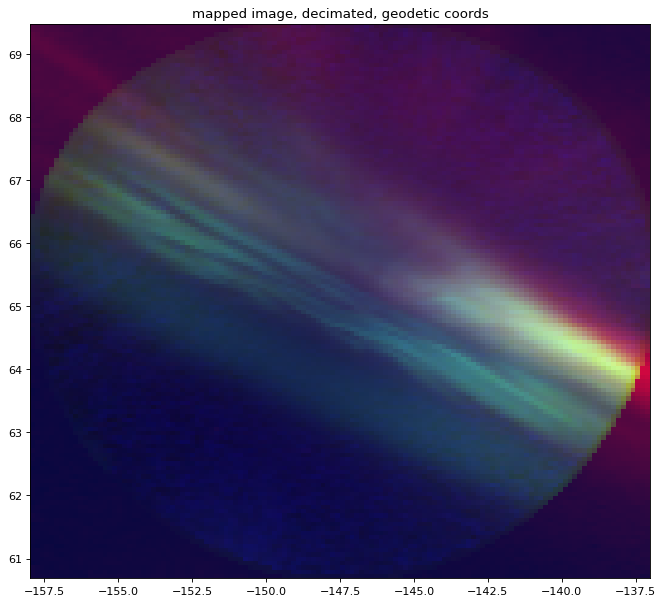

Text(0.5, 1.0, 'mapped image, decimated, geodetic coords - usable region only')

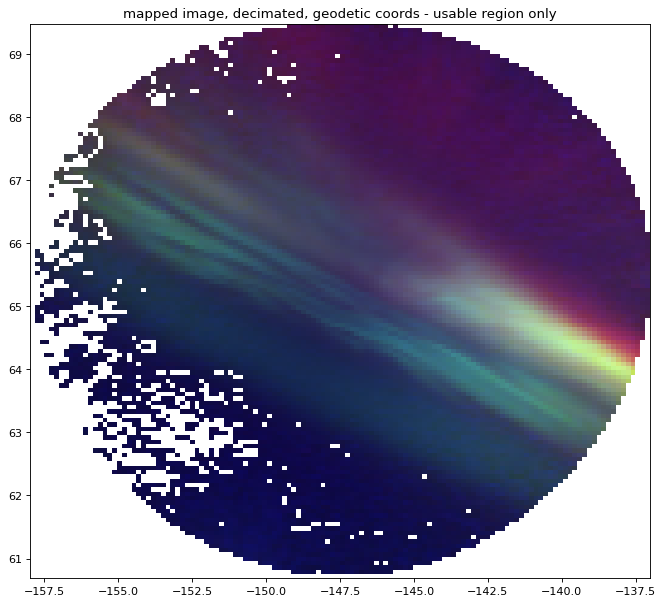

In [66]:
greenframe = np.copy(greenimdenoise)[::dec,::dec]
greenframe[np.where(np.isnan(greenframe))] = greenbgbright

blueframe = np.copy(blueimdenoise)[::dec,::dec]
blueframe[np.where(np.isnan(blueframe))] = bluebgbright

redframe = np.copy(redimdenoise)[::dec,::dec]
redframe[np.where(np.isnan(redframe))] = redbgbright

colormat = np.asarray([nred*(redframe-redmin).T,ngreen*(greenframe-greenmin).T,nblue*(blueframe-bluemin).T]).astype(float)

colormat /= maxbright

fig = figure(figsize=(10, 9), dpi=80)
fig.canvas.header_visible = False
mesh = plt.pcolormesh(decgridlon,decgridlat,greenframe,facecolors=colormat.T.reshape(-1,3),shading='nearest')
mesh.set_array(None)
plt.title('mapped image, decimated, geodetic coords')

plt.show()

colormat[0,:][np.where(negatives[::dec,::dec].T == 1)] = 1
colormat[1,:][np.where(negatives[::dec,::dec].T == 1)] = 1
colormat[2,:][np.where(negatives[::dec,::dec].T == 1)] = 1
colormat[0,:][np.where(np.isnan((redimdenoise+greenimdenoise+blueimdenoise)[::dec,::dec].T))] = 1
colormat[1,:][np.where(np.isnan((redimdenoise+greenimdenoise+blueimdenoise)[::dec,::dec].T))] = 1
colormat[2,:][np.where(np.isnan((redimdenoise+greenimdenoise+blueimdenoise)[::dec,::dec].T))] = 1


fig = figure(figsize=(10, 9), dpi=80)
fig.canvas.header_visible = False
mesh = plt.pcolormesh(decgridlon,decgridlat,greenframe,facecolors=colormat.T.reshape(-1,3))
mesh.set_array(None)
plt.title('mapped image, decimated, geodetic coords - usable region only')

## Invert to Q,E0
Calculate Q, E0 from image brightness

In [67]:
# Calculate E0 and Q from inversion
qout, e0out = calculate_E0_Q_v2(redraydec, greenraydec, blueraydec, v, minE0=150, secondorder=True, generous=True, plot=False)


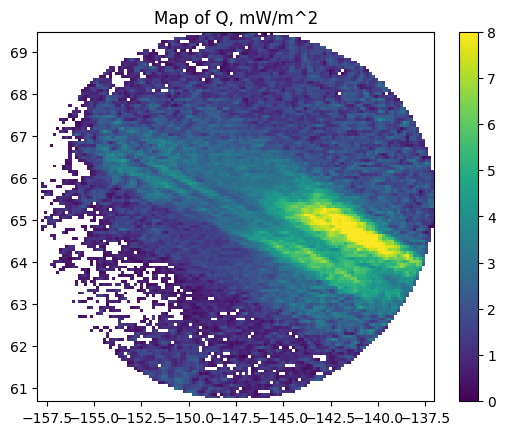

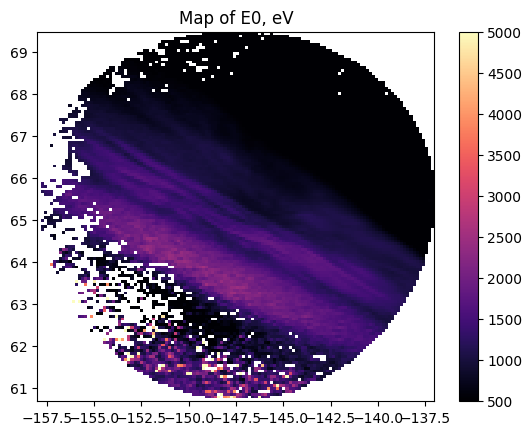

In [68]:
plt.title('Map of Q, mW/m^2')
plt.pcolormesh(decgridlon,decgridlat,qout,shading='nearest',vmin=0,vmax=8)
plt.colorbar()
plt.show()
plt.title('Map of E0, eV')
plt.pcolormesh(decgridlon,decgridlat,e0out,cmap='magma',vmin=500,vmax=5000,shading='nearest')
plt.colorbar()
plt.show()

## Calculate SigP, SigH
Note: The densities used for conductance estimation are zeroth order estimations above a certain altitude and should not be trusted!  In general, this calculation is not very good.  Recommended to take the inverted E0, Q and calculate conducances using an independent method.

In [69]:
SigP,SigH = calculate_Sig(qout,e0out,v,generous=False,plot=False)

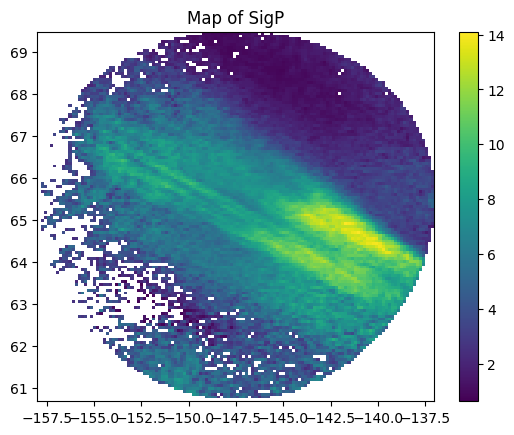

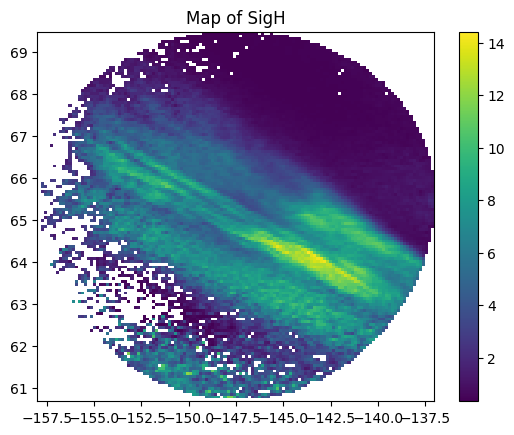

In [70]:
plt.title('Map of SigP')
plt.pcolormesh(decgridlon,decgridlat,SigP)
plt.colorbar()
plt.show()
plt.title('Map of SigH')
plt.pcolormesh(decgridlon,decgridlat,SigH)
plt.colorbar()
plt.show()

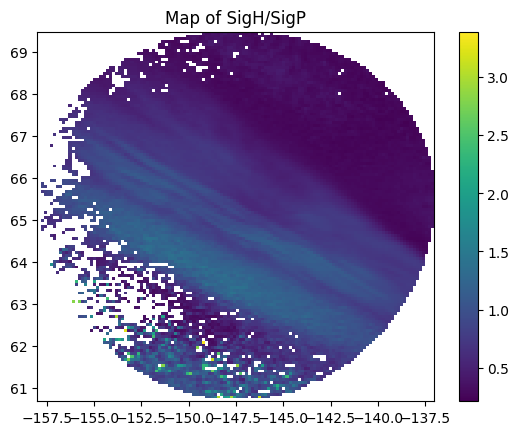

In [71]:
plt.title('Map of SigH/SigP')
plt.pcolormesh(decgridlon,decgridlat,SigH/SigP)
plt.colorbar()
plt.show()

## Invert Using R,G Brightness Only
This is an experimental technique.

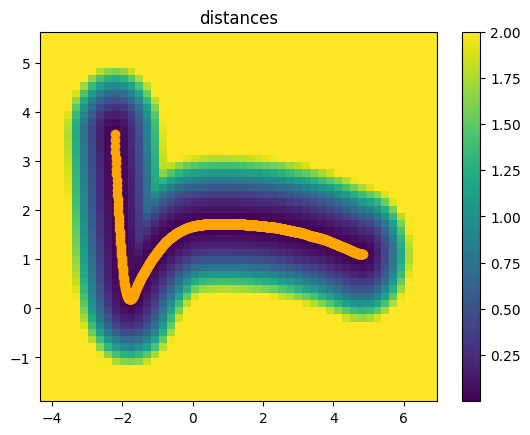

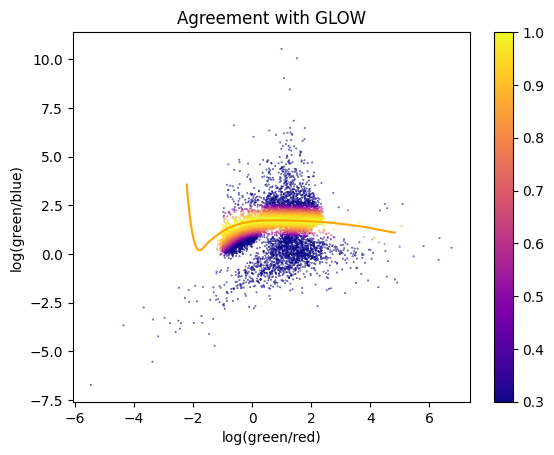

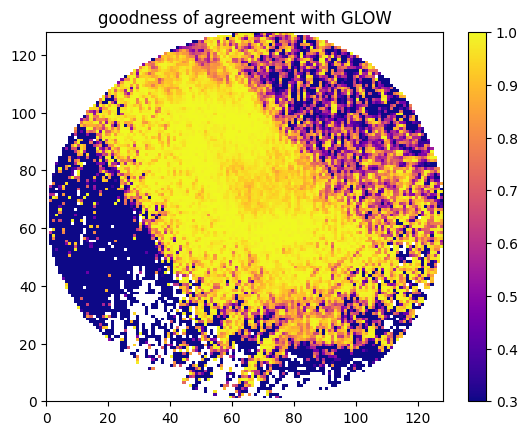

In [73]:
qoutrg,e0outrg = calculate_E0_Q_v2_RGonly(redraydec,greenraydec,blueraydec,v,minE0=150,checkagreement=True,cutoffgoodness=0.3,generous=False)

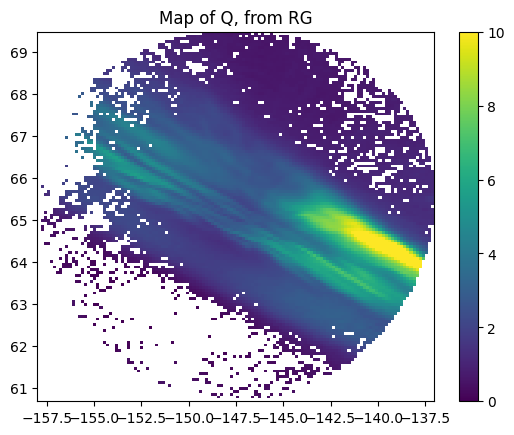

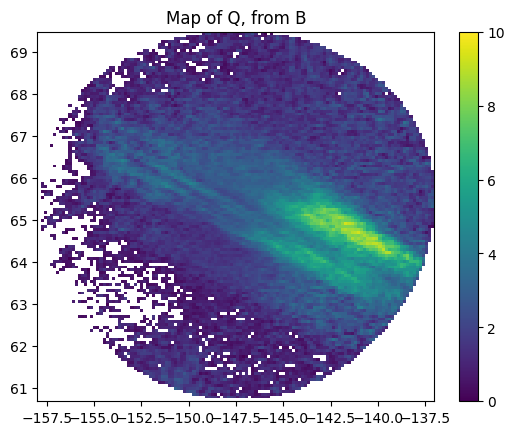

In [74]:
plt.title('Map of Q, from RG')
plt.pcolormesh(decgridlon,decgridlat,qoutrg,shading='nearest',vmin=0,vmax=10)
plt.colorbar()
plt.show()
plt.title('Map of Q, from B')
plt.pcolormesh(decgridlon,decgridlat,qout,shading='nearest',vmin=0,vmax=10)
plt.colorbar()
plt.show()